# Proyek Klasifikasi Gambar: Ikan Koi
- **Nama:** Naraya Albani
- **Email:** naraya.albani@gmail.com
- **ID Dicoding:** narayaalbani

## Import Semua Packages/Library yang Digunakan

In [ ]:
!pip install python-dotenv

In [ ]:
# Mengimpor libraries umum yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

# Mengimpor libraries untuk visualisasi
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread

# Mengimpor libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

# Mengimpor libraries untuk pembuatan dan evaluasi model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

## Data Preparation

### Data Loading

In [ ]:
import json
from dotenv import load_dotenv

load_dotenv()

# Isi dengan username Kaggle dan API key kamu
kaggle_credentials = {
    "username": os.getenv("USERNAME"),
    "key": os.getenv("API_KEY")
}

# Buat folder dan file kaggle.json
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_credentials, f)

# Set permission
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

print("kaggle.json berhasil dibuat!")

kaggle.json berhasil dibuat!


In [ ]:
# Download kaggle dataset and unzip the file
!kaggle datasets download -d farizp/dataset-images-koi
!unzip dataset-images-koi.zip

Dataset URL: https://www.kaggle.com/datasets/farizp/dataset-images-koi
License(s): unknown
100% 85.5M/85.5M [00:08<00:00, 11.0MB/s]

Archive:  dataset-images-koi.zip
  inflating: Dataset/Asagi/1 (1).jpg  
  inflating: Dataset/Asagi/1 (10).jpg  
  inflating: Dataset/Asagi/1 (100).jpg  
  inflating: Dataset/Asagi/1 (11).jpg  
  inflating: Dataset/Asagi/1 (12).jpg  
  inflating: Dataset/Asagi/1 (13).jpg  
  inflating: Dataset/Asagi/1 (14).jpg  
  inflating: Dataset/Asagi/1 (15).jpg  
  inflating: Dataset/Asagi/1 (16).jpg  
  inflating: Dataset/Asagi/1 (17).jpg  
  inflating: Dataset/Asagi/1 (18).jpg  
  inflating: Dataset/Asagi/1 (19).jpg  
  inflating: Dataset/Asagi/1 (2).jpg  
  inflating: Dataset/Asagi/1 (20).jpg  
  inflating: Dataset/Asagi/1 (21).jpg  
  inflating: Dataset/Asagi/1 (22).jpg  
  inflating: Dataset/Asagi/1 (23).jpg  
  inflating: Dataset/Asagi/1 (24).jpg  
  inflating: Dataset/Asagi/1 (25).jpg  
  inflating: Dataset/Asagi/1 (26).jpg  
  inflating: Dataset/Asagi/1 (27).j

### **Plot distribusi gambar di seluruh kelas**

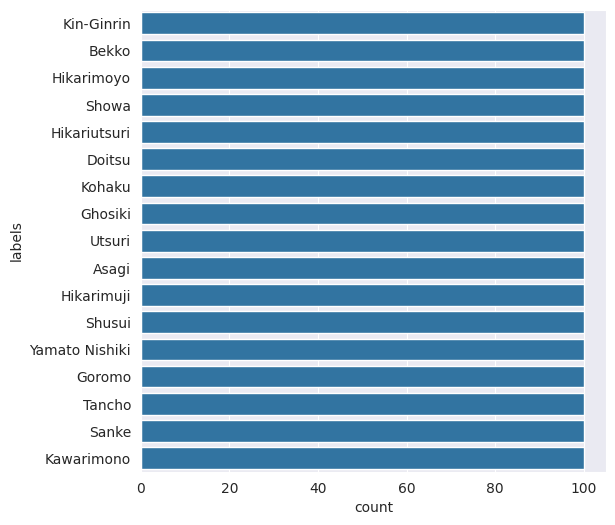

In [ ]:
# Define source path
path = "Dataset/"

# Create a list that stores data for each filenames, filepaths, and labels in the data
file_name = []
labels = []
full_path = []

# Get data image filenames, filepaths, labels one by one with looping, and store them as dataframe
for path, subdirs, files in os.walk(path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})

# Plot the distribution of images across the classes
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

### Data Preprocessing

#### Data Augmentation

In [ ]:
import scipy.ndimage as ndimage

# Membuat fungsi untuk melakukan rotasi berlawanan arah jarum jam
def anticlockwise_rotation(img):
    img = tf.image.resize(img, (224, 224))
    img = tf.image.rot90(img, k=random.randint(1, 3))  # Rotasi 90, 180, atau 270 derajat
    return img

# Membuat fungsi untuk melakukan rotasi searah jarum jam
def clockwise_rotation(img):
    img = tf.image.resize(img, (224, 224))
    img = tf.image.rot90(img, k=-random.randint(1, 3))  # Rotasi -90, -180, atau -270 derajat
    return img

# Membuat fungsi untuk membalik gambar secara vertikal dari atas ke bawah
def flip_up_down(img):
    img = tf.image.resize(img, (224, 224))
    img = tf.image.flip_up_down(img)
    return img

# Membuat fungsi untuk memberikan efek peningkatan kecerahan pada gambar
def add_brightness(img):
    img = tf.image.resize(img, (224, 224))
    img = tf.image.adjust_brightness(img, delta=random.uniform(0.05, 0.3))
    return img

# Membuat fungsi untuk memberikan efek blur pada gambar
# Menggunakan scipy.ndimage karena tf.image.random_blur tidak tersedia di TF versi terbaru
def blur_image(img):
    img = tf.image.resize(img, (224, 224))
    # Konversi ke numpy untuk diproses scipy
    if hasattr(img, 'numpy'):
        img_np = img.numpy().astype(np.float32)
    else:
        img_np = np.array(img, dtype=np.float32)
    sigma = random.uniform(0.5, 1.5)  # Tingkat blur acak
    blurred = ndimage.gaussian_filter(img_np, sigma=[sigma, sigma, 0])
    return blurred

# Membuat fungsi untuk memberikan efek shear/pergeseran pada gambar
def sheared(img):
    img = tf.image.resize(img, (224, 224))
    datagen = ImageDataGenerator(shear_range=0.2)
    if hasattr(img, 'numpy'):
        img = img.numpy()
    img_arr = np.clip(img, 0, 255).astype(np.uint8)
    img_arr = next(iter(datagen.flow(tf.expand_dims(img_arr, 0))))[0]
    return img_arr

# Membuat fungsi untuk melakukan pergeseran width/height pada gambar
def warp_shift(img):
    img = tf.image.resize(img, (224, 224))
    datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1)
    if hasattr(img, 'numpy'):
        img = img.numpy()
    img_arr = np.clip(img, 0, 255).astype(np.uint8)
    img_arr = next(iter(datagen.flow(tf.expand_dims(img_arr, 0))))[0]
    return img_arr

In [ ]:
import scipy.ndimage as ndimage

transformations = {
    'rotate anticlockwise': anticlockwise_rotation,
    'rotate clockwise': clockwise_rotation,
    'warp shift': warp_shift,
    'blurring image': blur_image,
    'add brightness': add_brightness,
    'flip up down': flip_up_down,
    'shear image': sheared
}

# Daftar kelas sesuai direktori Dataset yang ada
CLASS_NAMES = [
    'Asagi', 'Bekko', 'Doitsu', 'Ghosiki', 'Goromo',
    'Hikarimoyo', 'Hikarimuji', 'Hikariutsuri', 'Kawarimono',
    'Kin-Ginrin', 'Kohaku', 'Sanke', 'Showa', 'Shusui',
    'Tancho', 'Utsuri', 'Yamato Nishiki'
]

images_path = "Dataset/"   # Path direktori dataset asli
augmented_base = "Dataset_Augmented/"  # Path folder augmentasi dengan struktur kelas

# Buat subfolder augmented per kelas sesuai struktur Dataset asli
for class_name in CLASS_NAMES:
    os.makedirs(os.path.join(augmented_base, class_name), exist_ok=True)

# Kumpulkan semua path gambar beserta label kelasnya
images = []  # List of (image_path, class_name)
for class_name in CLASS_NAMES:
    class_dir = os.path.join(images_path, class_name)
    if not os.path.isdir(class_dir):
        print(f'[WARNING] Folder tidak ditemukan: {class_dir}')
        continue
    for file in os.listdir(class_dir):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            images.append((os.path.join(class_dir, file), class_name))

print(f"Total gambar asli ditemukan: {len(images)}")
print(f"Kelas yang ditemukan: {list(set([c for _, c in images]))}")

# Jumlah gambar augmented yang akan dibuat per kelas
images_to_generate_per_class = 200  # Total augmented = 200 x 17 kelas = 3400

total_generated = 0
total_skipped = 0

for class_name in CLASS_NAMES:
    # Filter gambar untuk kelas ini
    class_images = [path for path, cls in images if cls == class_name]
    if not class_images:
        print(f'[SKIP] Tidak ada gambar untuk kelas: {class_name}')
        continue

    aug_class_dir = os.path.join(augmented_base, class_name)
    i = 1

    while i <= images_to_generate_per_class:
        image_path = random.choice(class_images)
        try:
            original_image = io.imread(image_path)

            # Periksa dimensi gambar valid (RGB = 3 channel)
            if original_image.ndim == 2:  # Grayscale -> convert ke RGB
                original_image = np.stack([original_image]*3, axis=-1)
            elif original_image.shape[-1] == 4:  # RGBA -> buang alpha channel
                original_image = original_image[:, :, :3]
            elif original_image.ndim != 3:
                raise ValueError(f'Dimensi gambar tidak valid: {original_image.shape}')

            transformed_image = original_image.copy()
            transformation_count = random.randint(1, len(transformations))
            n = 0

            while n < transformation_count:
                key = random.choice(list(transformations))
                transformed_image = transformations[key](transformed_image)

                # Normalisasi hasil ke uint8
                if hasattr(transformed_image, 'numpy'):
                    transformed_image = transformed_image.numpy()
                transformed_image = np.clip(transformed_image, 0, 255).astype(np.uint8)
                n += 1

            # Simpan hasil augmentasi ke subfolder kelas yang sesuai
            new_image_path = os.path.join(aug_class_dir, f'aug_{class_name}_{i}.jpg')
            cv2.imwrite(new_image_path, cv2.cvtColor(transformed_image, cv2.COLOR_RGB2BGR))
            i += 1
            total_generated += 1

        except Exception as e:
            total_skipped += 1
            print(f'[ERROR] Gagal memproses {image_path}: {e}')

    print(f'[OK] {class_name}: {images_to_generate_per_class} gambar augmented tersimpan di {aug_class_dir}')

print(f'\nSelesai! Total augmented: {total_generated}, Skipped: {total_skipped}')
print(f'Struktur Dataset_Augmented:')
for class_name in CLASS_NAMES:
    aug_dir = os.path.join(augmented_base, class_name)
    count = len([f for f in os.listdir(aug_dir) if f.endswith('.jpg')]) if os.path.isdir(aug_dir) else 0
    print(f'  {class_name}: {count} gambar')

Total gambar asli ditemukan: 1700
Kelas yang ditemukan: ['Sanke', 'Kin-Ginrin', 'Kohaku', 'Tancho', 'Bekko', 'Doitsu', 'Showa', 'Kawarimono', 'Goromo', 'Ghosiki', 'Shusui', 'Utsuri', 'Yamato Nishiki', 'Hikariutsuri', 'Hikarimuji', 'Asagi', 'Hikarimoyo']
[OK] Asagi: 200 gambar augmented tersimpan di Dataset_Augmented/Asagi
[OK] Bekko: 200 gambar augmented tersimpan di Dataset_Augmented/Bekko
[OK] Doitsu: 200 gambar augmented tersimpan di Dataset_Augmented/Doitsu
[OK] Ghosiki: 200 gambar augmented tersimpan di Dataset_Augmented/Ghosiki
[OK] Goromo: 200 gambar augmented tersimpan di Dataset_Augmented/Goromo
[OK] Hikarimoyo: 200 gambar augmented tersimpan di Dataset_Augmented/Hikarimoyo
[OK] Hikarimuji: 200 gambar augmented tersimpan di Dataset_Augmented/Hikarimuji
[OK] Hikariutsuri: 200 gambar augmented tersimpan di Dataset_Augmented/Hikariutsuri
[OK] Kawarimono: 200 gambar augmented tersimpan di Dataset_Augmented/Kawarimono
[OK] Kin-Ginrin: 200 gambar augmented tersimpan di Dataset_Augme

#### Split Dataset

In [ ]:
# Path sumber: dataset asli + dataset augmented
SOURCE_DIRS = ['Dataset', 'Dataset_Augmented']

SPLIT_BASE = 'dataset_split'
TRAIN_DIR  = os.path.join(SPLIT_BASE, 'train')
VAL_DIR    = os.path.join(SPLIT_BASE, 'val')
TEST_DIR   = os.path.join(SPLIT_BASE, 'test')

# Buat subfolder tujuan per kelas
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for class_name in CLASS_NAMES:
        os.makedirs(os.path.join(split_dir, class_name), exist_ok=True)

# Kumpulkan semua path gambar dan labelnya
all_image_paths = []
all_labels      = []

for class_name in CLASS_NAMES:
    for src in SOURCE_DIRS:
        class_dir = os.path.join(src, class_name)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_image_paths.append(os.path.join(class_dir, fname))
                all_labels.append(class_name)

print(f'Total gambar terkumpul: {len(all_image_paths)} dari {len(set(all_labels))} kelas')

# ---- Tahap 1: pisahkan train (70%) vs sisa (30%) ----
# stratify=all_labels menjamin proporsi tiap kelas terjaga di setiap split
X_train, X_temp, y_train, y_temp = train_test_split(
    all_image_paths,
    all_labels,
    test_size=0.30,
    random_state=42,
    stratify=all_labels
)

# ---- Tahap 2: pisahkan sisa menjadi val (15%) dan test (15%) ----
# test_size=0.50 dari 30% sisa = 15% total masing-masing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f'Train : {len(X_train)} gambar (70%)')
print(f'Val   : {len(X_val)} gambar (15%)')
print(f'Test  : {len(X_test)} gambar (15%)')

# ---- Salin gambar ke folder split yang sesuai ----
def copy_files(paths, labels, dest_dir):
    for img_path, label in zip(paths, labels):
        dst = os.path.join(dest_dir, label, os.path.basename(img_path))
        shutil.copy(img_path, dst)

copy_files(X_train, y_train, TRAIN_DIR)
copy_files(X_val,   y_val,   VAL_DIR)
copy_files(X_test,  y_test,  TEST_DIR)

# ---- Tampilkan ringkasan per kelas ----
print(f'\n{"Kelas":<20} {"Total":>7} {"Train":>7} {"Val":>7} {"Test":>7}')
print('-' * 52)
for class_name in CLASS_NAMES:
    total = all_labels.count(class_name)
    n_tr  = y_train.count(class_name)
    n_vl  = y_val.count(class_name)
    n_te  = y_test.count(class_name)
    print(f'{class_name:<20} {total:>7} {n_tr:>7} {n_vl:>7} {n_te:>7}')
print('-' * 52)
print(f'{"TOTAL":<20} {len(all_labels):>7} {len(y_train):>7} {len(y_val):>7} {len(y_test):>7}')
print(f'\nDataset split tersimpan di folder: {SPLIT_BASE}/')

Total gambar terkumpul: 5100 dari 17 kelas
Train : 3570 gambar (70%)
Val   : 765 gambar (15%)
Test  : 765 gambar (15%)

Kelas                  Total   Train     Val    Test
----------------------------------------------------
Asagi                    300     210      45      45
Bekko                    300     210      45      45
Doitsu                   300     210      45      45
Ghosiki                  300     210      45      45
Goromo                   300     210      45      45
Hikarimoyo               300     210      45      45
Hikarimuji               300     210      45      45
Hikariutsuri             300     210      45      45
Kawarimono               300     210      45      45
Kin-Ginrin               300     210      45      45
Kohaku                   300     210      45      45
Sanke                    300     210      45      45
Showa                    300     210      45      45
Shusui                   300     210      45      45
Tancho                   300    

Found 3570 images belonging to 17 classes.
Found 765 images belonging to 17 classes.
Found 765 images belonging to 17 classes.
=== INFO GENERATOR ===
Jumlah kelas       : 17
Label kelas        : ['Asagi', 'Bekko', 'Doitsu', 'Ghosiki', 'Goromo', 'Hikarimoyo', 'Hikarimuji', 'Hikariutsuri', 'Kawarimono', 'Kin-Ginrin', 'Kohaku', 'Sanke', 'Showa', 'Shusui', 'Tancho', 'Utsuri', 'Yamato Nishiki']

Train  - gambar: 3570, batch: 112
Val    - gambar: 765,   batch: 24
Test   - gambar: 765,  batch: 24


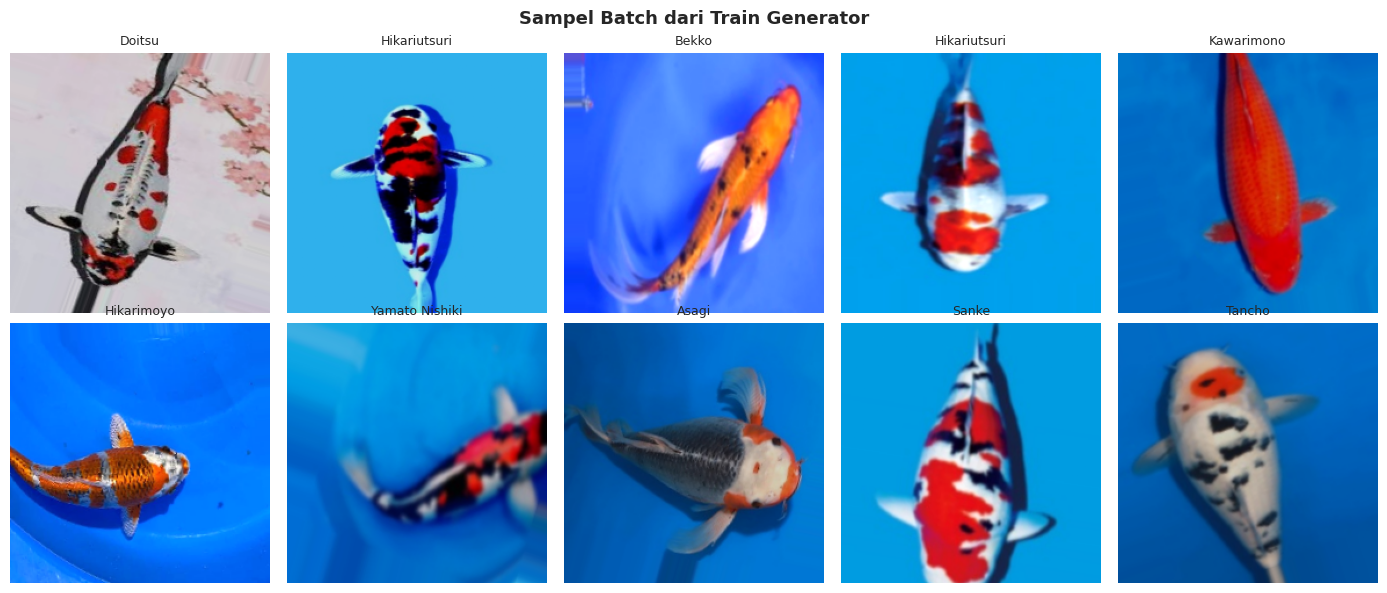

In [ ]:
# ============================================================
# IMAGE GENERATOR: Train | Validation | Test
# Menggunakan tf.keras.preprocessing.image.ImageDataGenerator
# ============================================================

IMG_SIZE   = (224, 224)   # Ukuran input model
BATCH_SIZE = 32

# ---- Generator Train: dengan augmentasi ringan on-the-fly ----
# Augmentasi tambahan saat training agar model lebih robust
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalisasi piksel ke [0, 1]
    horizontal_flip=True,     # Flip horizontal acak
    vertical_flip=True,       # Flip vertikal acak
    rotation_range=20,        # Rotasi acak ±20 derajat
    zoom_range=0.15,          # Zoom acak ±15%
    width_shift_range=0.1,    # Geser horizontal ±10%
    height_shift_range=0.1,   # Geser vertikal ±10%
    shear_range=0.1,          # Shear ±10%
    brightness_range=[0.8, 1.2],  # Variasi kecerahan
    fill_mode='nearest'       # Isi piksel kosong dengan tetangga terdekat
)

# ---- Generator Val & Test: hanya rescale, tanpa augmentasi ----
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

# ---- Buat generator dari folder dataset_split ----
train_generator = train_datagen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # One-hot encoding untuk multi-class
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    directory=VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    directory=TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ---- Informasi generator ----
print('=== INFO GENERATOR ===')
print(f'Jumlah kelas       : {train_generator.num_classes}')
print(f'Label kelas        : {list(train_generator.class_indices.keys())}')
print()
print(f'Train  - gambar: {train_generator.samples}, batch: {len(train_generator)}')
print(f'Val    - gambar: {val_generator.samples},   batch: {len(val_generator)}')
print(f'Test   - gambar: {test_generator.samples},  batch: {len(test_generator)}')

# ---- Visualisasi sampel batch dari train generator ----
images_batch, labels_batch = next(train_generator)
class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(14, 6))
for idx in range(min(10, BATCH_SIZE)):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(images_batch[idx])
    label_idx = np.argmax(labels_batch[idx])
    plt.title(class_names[label_idx], fontsize=9)
    plt.axis('off')
plt.suptitle('Sampel Batch dari Train Generator', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Modelling

In [ ]:
# ============================================================
# MODEL CNN - Klasifikasi Ikan Koi (17 Kelas)
# Arsitektur: Custom CNN + Transfer Learning MobileNetV2
# Input: 224x224x3 | Output: 17 kelas (softmax)
# ============================================================

NUM_CLASSES = train_generator.num_classes  # 17 kelas
IMG_SHAPE   = (224, 224, 3)

# ------------------------------------------------------------
# BASE MODEL: MobileNetV2 pretrained ImageNet (transfer learning)
# Dipilih karena:
#   - Ringan & efisien untuk dataset gambar binatang/alam
#   - Fitur low-level (tepi, tekstur, warna) sudah terlatih
#     sangat relevan untuk membedakan pola sisik & warna koi
#   - Cocok untuk 17 kelas dengan ~300 gambar/kelas
# ------------------------------------------------------------
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,       # Hapus fully-connected layer asli
    weights='imagenet'       # Gunakan bobot pretrained ImageNet
)

# Bekukan semua layer base model dulu (feature extraction phase)
base_model.trainable = False

# ------------------------------------------------------------
# ARSITEKTUR MODEL
# ------------------------------------------------------------
model = Sequential([
    # --- Input ---
    InputLayer(input_shape=IMG_SHAPE),

    # --- Feature Extraction (MobileNetV2) ---
    base_model,

    # --- Custom Head ---
    # Global Average Pooling menggantikan Flatten
    # untuk mengurangi parameter & mencegah overfitting
    layers.GlobalAveragePooling2D(),

    # Dense block 1
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Dense block 2
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # --- Output Layer ---
    # Softmax untuk klasifikasi 17 kelas
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# ------------------------------------------------------------
# COMPILE MODEL
# ------------------------------------------------------------
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ------------------------------------------------------------
# CALLBACKS
# ------------------------------------------------------------
callbacks = [
    # Simpan bobot model terbaik berdasarkan val_accuracy
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Hentikan training jika val_loss tidak membaik setelah 10 epoch
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Kurangi learning rate jika val_loss stagnan setelah 5 epoch
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# ------------------------------------------------------------
# PHASE 1: TRAINING (base model frozen)
# ------------------------------------------------------------
print('=== Phase 1: Feature Extraction (base model frozen) ===')
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

# ------------------------------------------------------------
# PHASE 2: FINE-TUNING (unfreeze 50 layer terakhir base model)
# Dilakukan setelah phase 1 agar head sudah terlatih lebih dulu
# sehingga gradien tidak merusak bobot pretrained
# ------------------------------------------------------------
print('\n=== Phase 2: Fine-Tuning (50 layer terakhir di-unfreeze) ===')
base_model.trainable = True

# Bekukan layer-layer awal, unfreeze hanya 50 layer terakhir
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Gunakan learning rate lebih kecil agar tidak merusak bobot pretrained
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

# ------------------------------------------------------------
# PLOT TRAINING HISTORY (Phase 1 + Phase 2 digabung)
# ------------------------------------------------------------
def plot_history(h1, h2=None):
    acc  = h1.history['accuracy']
    val_acc  = h1.history['val_accuracy']
    loss = h1.history['loss']
    val_loss = h1.history['val_loss']

    if h2:
        acc      += h2.history['accuracy']
        val_acc  += h2.history['val_accuracy']
        loss     += h2.history['loss']
        val_loss += h2.history['val_loss']
        fine_start = len(h1.history['accuracy'])
    else:
        fine_start = None

    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot
    axes[0].plot(epochs_range, acc,     label='Train Accuracy')
    axes[0].plot(epochs_range, val_acc, label='Val Accuracy')
    if fine_start:
        axes[0].axvline(fine_start, color='gray', linestyle='--', label='Fine-tune start')
    axes[0].set_title('Accuracy per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Loss plot
    axes[1].plot(epochs_range, loss,     label='Train Loss')
    axes[1].plot(epochs_range, val_loss, label='Val Loss')
    if fine_start:
        axes[1].axvline(fine_start, color='gray', linestyle='--', label='Fine-tune start')
    axes[1].set_title('Loss per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle('Training History: Phase 1 + Phase 2 Fine-Tuning', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history, history_fine)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,052,625 (11.64 MB)

 Trainable params: 793,105 (3.03 MB)

 Non-trainable params: 2,259,520 (8.62 MB)

=== Phase 1: Feature Extraction (base model frozen) ===
Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3207 - loss: 2.3997
Epoch 1: val_accuracy improved from None to 0.57124, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
112/112 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.4210 - loss: 1.9366 - val_accuracy: 0.5712 - val_loss: 1.3130 - learning_rate: 0.0010
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5913 - loss: 1.3005
Epoch 2: val_accuracy improved from 0.57124 to 0.69020, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
112/112 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - accuracy: 0.5980 - loss: 1.2724 - val_accuracy: 0.6902 - val_loss: 0.9129 - learning_rate: 0.0010
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6274 - loss: 1.1209
Epoch 3: val_accuracy improved from 0.69020 to 0.71242, saving model to best_model.keras

Epoch 3: finished saving model to be

Model berhasil di-load dari best_model.keras


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,638,837 (17.70 MB)

 Trainable params: 793,105 (3.03 MB)

 Non-trainable params: 2,259,520 (8.62 MB)

 Optimizer params: 1,586,212 (6.05 MB)

Layer base model yang di-unfreeze: 50 layer

Melanjutkan training dari epoch 50 hingga epoch 80...
Epoch 51/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6011 - loss: 1.4530
Epoch 51: val_accuracy improved from None to 0.77908, saving model to best_model_resumed.keras

Epoch 51: finished saving model to best_model_resumed.keras
112/112 ━━━━━━━━━━━━━━━━━━━━ 387s 3s/step - accuracy: 0.6140 - loss: 1.3886 - val_accuracy: 0.7791 - val_loss: 0.6486 - learning_rate: 1.0000e-05
Epoch 52/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6640 - loss: 1.1594
Epoch 52: val_accuracy did not improve from 0.77908
112/112 ━━━━━━━━━━━━━━━━━━━━ 365s 3s/step - accuracy: 0.6728 - loss: 1.1124 - val_accuracy: 0.7516 - val_loss: 0.8389 - learning_rate: 1.0000e-05
Epoch 53/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7041 - loss: 0.9378
Epoch 53: val_accuracy did not improve from 0.77908
112/112 ━━━━━━━━━━━━━━━━━━━━ 364s 3s/step - accuracy: 0.7048 - loss: 0.9497 - val_accuracy:

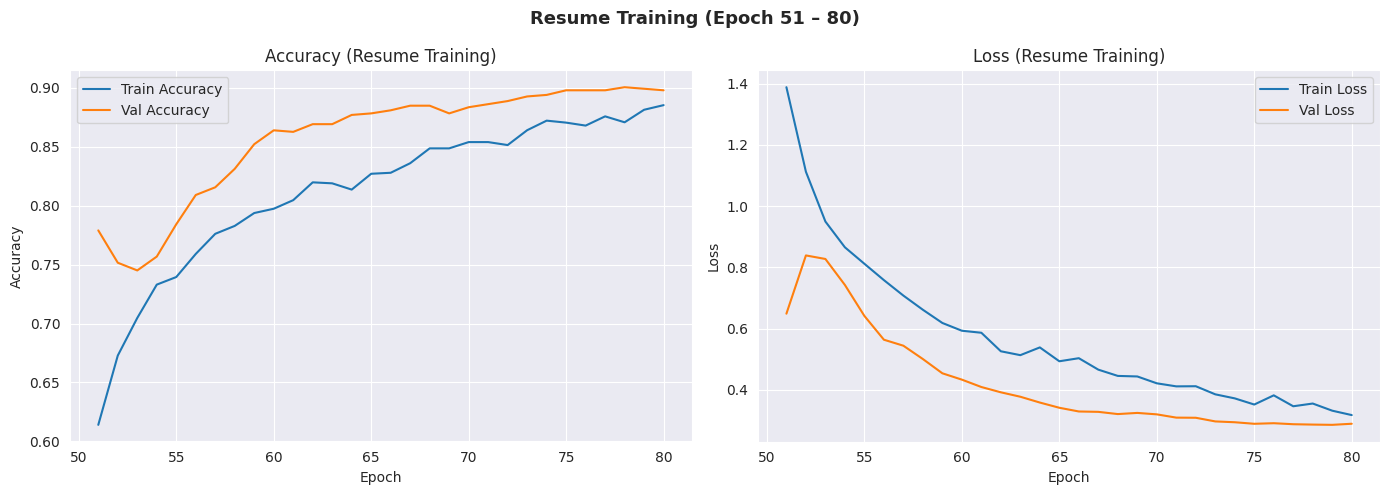


Model terbaik (resumed) tersimpan di: best_model_resumed.keras


In [ ]:
# ============================================================
# RESUME TRAINING DARI best_model.keras
# Jalankan cell ini TANPA perlu menjalankan ulang cell Modelling
# Syarat: train_generator & val_generator sudah aktif
# ============================================================

# ------------------------------------------------------------
# STEP 1: Load model checkpoint terbaik
# ------------------------------------------------------------
model = tf.keras.models.load_model('best_model.keras')
print('Model berhasil di-load dari best_model.keras')
model.summary()

# ------------------------------------------------------------
# STEP 2: Cek epoch terakhir dari history sebelumnya
# Ganti nilai ini sesuai epoch terakhir yang sudah berjalan
# (Phase 1 = 30 epoch, Phase 2 = hingga early stopping)
# Contoh: jika total sudah 42 epoch → LAST_EPOCH = 42
# ------------------------------------------------------------
LAST_EPOCH = 50   # <-- sesuaikan dengan epoch terakhirmu

# ------------------------------------------------------------
# STEP 3: Unfreeze base model untuk fine-tuning lanjutan
# Ambil layer MobileNetV2 (index 1 di Sequential)
# ------------------------------------------------------------
base_model = model.get_layer('mobilenetv2_1.00_224')  # MobileNetV2
base_model.trainable = True

# Bekukan layer awal, hanya unfreeze 50 layer terakhir
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Layer base model yang di-unfreeze: {trainable_count} layer')

# ------------------------------------------------------------
# STEP 4: Compile ulang dengan learning rate lebih kecil
# LR lebih kecil dari sebelumnya agar bobot pretrained
# tidak rusak saat dilanjutkan
# ------------------------------------------------------------
model.compile(
    optimizer=Adam(learning_rate=1e-5),   # lebih kecil dari phase 2 (1e-4)
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------------------------------------------------
# STEP 5: Callbacks — checkpoint baru agar tidak menimpa
# ------------------------------------------------------------
resume_callbacks = [
    ModelCheckpoint(
        filepath='best_model_resumed.keras',  # simpan ke file baru
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# ------------------------------------------------------------
# STEP 6: Lanjutkan training
# initial_epoch = epoch terakhir agar counter tidak reset ke 0
# epochs        = total epoch target akhir
# ------------------------------------------------------------
TARGET_EPOCH = LAST_EPOCH + 30  # tambah 30 epoch lagi

print(f'\nMelanjutkan training dari epoch {LAST_EPOCH} hingga epoch {TARGET_EPOCH}...')
history_resumed = model.fit(
    train_generator,
    initial_epoch=LAST_EPOCH,
    epochs=TARGET_EPOCH,
    validation_data=val_generator,
    callbacks=resume_callbacks,
    verbose=1
)

# ------------------------------------------------------------
# STEP 7: Plot hasil training lanjutan
# ------------------------------------------------------------
acc      = history_resumed.history['accuracy']
val_acc  = history_resumed.history['val_accuracy']
loss     = history_resumed.history['loss']
val_loss = history_resumed.history['val_loss']
epochs_range = range(LAST_EPOCH + 1, LAST_EPOCH + len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, acc,    label='Train Accuracy')
axes[0].plot(epochs_range, val_acc, label='Val Accuracy')
axes[0].set_title('Accuracy (Resume Training)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, loss,    label='Train Loss')
axes[1].plot(epochs_range, val_loss, label='Val Loss')
axes[1].set_title('Loss (Resume Training)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f'Resume Training (Epoch {LAST_EPOCH+1} – {LAST_EPOCH+len(acc)})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nModel terbaik (resumed) tersimpan di: best_model_resumed.keras')

## Evaluasi dan Visualisasi

In [ ]:
# ============================================================
# EVALUASI DAN VISUALISASI MODEL
# 1. Evaluasi pada Test Set
# 2. Classification Report
# 3. Confusion Matrix
# 4. Visualisasi Prediksi Sampel
# 5. Top-3 Confident Predictions & Misclassifications
# ============================================================

import itertools

class_names = list(test_generator.class_indices.keys())

# ------------------------------------------------------------
# 1. EVALUASI METRIK PADA TEST SET
# ------------------------------------------------------------
print('=== Evaluasi pada Test Set ===')
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc*100:.2f}%')

# ------------------------------------------------------------
# 2. PREDIKSI SELURUH TEST SET
# ------------------------------------------------------------
# Reset generator agar prediksi dimulai dari awal
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)   # Indeks kelas prediksi
y_true       = test_generator.classes             # Label ground truth

# ------------------------------------------------------------
# 3. CLASSIFICATION REPORT
# ------------------------------------------------------------
print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=class_names))

# ------------------------------------------------------------
# 4. CONFUSION MATRIX
# ------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(18, 15))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

tick_marks = np.arange(len(class_names))
ax.set_xticks(tick_marks)
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
ax.set_yticks(tick_marks)
ax.set_yticklabels(class_names, fontsize=10)

# Anotasi nilai di tiap sel
thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, format(cm[i, j], 'd'),
            ha='center', va='center',
            color='white' if cm[i, j] > thresh else 'black',
            fontsize=9)

ax.set_ylabel('Label Aktual', fontsize=12)
ax.set_xlabel('Label Prediksi', fontsize=12)
ax.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. PER-CLASS ACCURACY BAR CHART
# ------------------------------------------------------------
per_class_acc = cm.diagonal() / cm.sum(axis=1)

colors = ['#2ecc71' if acc >= 0.80 else '#e67e22' if acc >= 0.60 else '#e74c3c'
          for acc in per_class_acc]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(class_names, per_class_acc * 100, color=colors, edgecolor='white', linewidth=0.8)
ax.set_xlabel('Kelas', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Accuracy pada Test Set', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 110)
ax.axhline(y=test_acc * 100, color='steelblue', linestyle='--', linewidth=1.5,
           label=f'Overall Accuracy: {test_acc*100:.1f}%')
ax.legend(fontsize=10)

# Label nilai di atas tiap bar
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=8)

# Legenda warna
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='≥ 80% (Baik)'),
    Patch(facecolor='#e67e22', label='60–79% (Cukup)'),
    Patch(facecolor='#e74c3c', label='< 60% (Perlu Perbaikan)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. VISUALISASI SAMPEL PREDIKSI BENAR & SALAH
# ------------------------------------------------------------
def show_predictions(generator, y_true, y_pred, y_pred_probs, class_names,
                     correct=True, n=10):
    """Tampilkan n sampel prediksi benar atau salah."""
    mask    = (y_pred == y_true) if correct else (y_pred != y_true)
    indices = np.where(mask)[0]
    if len(indices) == 0:
        print('Tidak ada sampel yang memenuhi kriteria.')
        return

    # Ambil path gambar dari generator
    all_paths = [generator.filepaths[i] for i in indices[:n]]

    title_str = 'Prediksi BENAR ✅' if correct else 'Prediksi SALAH ❌'
    n_show = min(n, len(all_paths))
    cols = 5
    rows = (n_show + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3.5))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

    for ax_idx, img_path in enumerate(all_paths):
        orig_idx    = indices[ax_idx]
        true_label  = class_names[y_true[orig_idx]]
        pred_label  = class_names[y_pred[orig_idx]]
        confidence  = y_pred_probs[orig_idx][y_pred[orig_idx]] * 100

        img = Image.open(img_path).resize((224, 224))
        axes[ax_idx].imshow(img)
        axes[ax_idx].axis('off')

        color = 'green' if correct else 'red'
        axes[ax_idx].set_title(
            f'Aktual : {true_label}\nPrediksi: {pred_label}\nConf: {confidence:.1f}%',
            fontsize=8, color=color
        )

    # Sembunyikan axes kosong
    for ax_idx in range(n_show, len(axes)):
        axes[ax_idx].axis('off')

    plt.suptitle(title_str, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

print('\n=== Sampel Prediksi Benar ===')
show_predictions(test_generator, y_true, y_pred, y_pred_probs, class_names,
                 correct=True, n=10)

print('\n=== Sampel Prediksi Salah ===')
show_predictions(test_generator, y_true, y_pred, y_pred_probs, class_names,
                 correct=False, n=10)

# ------------------------------------------------------------
# 7. TOP-3 PROBABILITAS PREDIKSI (sampel acak)
# ------------------------------------------------------------
print('\n=== Visualisasi Top-3 Probabilitas Prediksi ===')
sample_indices = np.random.choice(len(y_true), size=6, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for col, idx in enumerate(sample_indices):
    img_path   = test_generator.filepaths[idx]
    true_label = class_names[y_true[idx]]
    probs      = y_pred_probs[idx]
    top3_idx   = np.argsort(probs)[::-1][:3]
    top3_names = [class_names[i] for i in top3_idx]
    top3_probs = [probs[i] * 100 for i in top3_idx]

    # Baris atas: gambar
    img = Image.open(img_path).resize((224, 224))
    axes[0, col].imshow(img)
    axes[0, col].axis('off')
    pred_correct = (y_pred[idx] == y_true[idx])
    title_color  = 'green' if pred_correct else 'red'
    axes[0, col].set_title(f'Aktual:\n{true_label}', fontsize=8,
                            color=title_color, fontweight='bold')

    # Baris bawah: bar chart probabilitas
    bar_colors = ['#2ecc71' if n == true_label else '#3498db' for n in top3_names]
    axes[1, col].barh(top3_names[::-1], top3_probs[::-1], color=bar_colors[::-1])
    axes[1, col].set_xlim(0, 100)
    axes[1, col].set_xlabel('Probabilitas (%)', fontsize=7)
    axes[1, col].tick_params(axis='y', labelsize=7)
    axes[1, col].tick_params(axis='x', labelsize=7)
    for i, (name, prob) in enumerate(zip(top3_names[::-1], top3_probs[::-1])):
        axes[1, col].text(prob + 1, i, f'{prob:.1f}%', va='center', fontsize=7)

plt.suptitle('Top-3 Probabilitas Prediksi pada Sampel Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Konversi Model

In [ ]:
# Load model hasil resumed training
model_final = tf.keras.models.load_model('best_model_resumed.keras')
print("✅ Model loaded:", model_final.input_shape, "→", model_final.output_shape)

# Simpan ke H5
model_final.save('best_model_resumed.h5')
print("✅ Tersimpan sebagai best_model_resumed.h5")

# Verifikasi
verify = tf.keras.models.load_model('best_model_resumed.h5')
verify.summary()
print("✅ Verifikasi H5 berhasil!")

✅ Model loaded: (None, 224, 224, 3) → (None, 17)
✅ Tersimpan sebagai best_model_resumed.h5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,052,627 (11.64 MB)

 Trainable params: 2,648,209 (10.10 MB)

 Non-trainable params: 404,416 (1.54 MB)

 Optimizer params: 2 (12.00 B)

✅ Verifikasi H5 berhasil!


In [ ]:
# Konversi ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

os.makedirs('submission/tflite', exist_ok=True)

# Simpan model.tflite
with open('submission/tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

# Buat label.txt — sesuaikan dengan kelas kamu
# Ambil otomatis dari train_generator
labels = list(train_generator.class_indices.keys())
with open('submission/tflite/label.txt', 'w') as f:
    f.write('\n'.join(labels))

print("✅ TFLite tersimpan")
print("Label:", labels)

Saved artifact at '/tmp/tmp5e7rnj07'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 17), dtype=tf.float32, name=None)
Captures:
  134059621016656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621018384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621018192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621007632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621018960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621017616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621018576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621018768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621016272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621019920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621019

In [ ]:
!pip install tensorflowjs -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.40.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
db-dtypes 1.5.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.


In [ ]:
import tensorflowjs as tfjs

os.makedirs('submission/tfjs_model', exist_ok=True)

tfjs.converters.save_keras_model(model, 'submission/tfjs_model')
print("✅ TFJS tersimpan")

failed to lookup keras version from the file,
    this is likely a weight only file
✅ TFJS tersimpan


In [ ]:
import os

os.makedirs('submission/saved_model', exist_ok=True)

# Cara 1: Gunakan model.export() — lebih stabil untuk Keras 3
try:
    model.export('submission/saved_model')
    print("✅ SavedModel tersimpan (via model.export)")

except Exception as e:
    print(f"Cara 1 gagal: {e}")

    # Cara 2: Save as .keras dulu, lalu convert
    try:
        model.save('submission/saved_model', save_format='tf')
        print("✅ SavedModel tersimpan (via save_format='tf')")

    except Exception as e2:
        print(f"Cara 2 gagal: {e2}")

        # Cara 3: Rebuild via TFSMLayer
        model.save('temp_model.keras')
        loaded = tf.keras.layers.TFSMLayer('temp_model.keras', call_endpoint='serving_default')
        print("✅ Loaded via TFSMLayer")

Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 17), dtype=tf.float32, name=None)
Captures:
  134059621016656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621018384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621018192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621007632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621018960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621017616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621018576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621018768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621016272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059621019920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134059

## Inference (Optional)